In [34]:
import pandas as pd

In [35]:
df =  pd.read_csv("data/main/dataset.csv")

In [36]:
df.shape

(411, 83)

In [9]:
df 

,Unnamed: 0,repo_name,num_contributors,total_contributions,top1_contribution_share,top5_contribution_share,contribution_gini,median_contributions,num_deployments,has_deployments,...,contributors_to_stars_ratio,tag_release_velocity,interaction_ratio,development_ratio,external_interest_event_ratio,stars_per_size,forks_per_size,issues_per_size,error,label
0,0,feast-dev/feast,30.0,3139.0,0.173941,0.475948,0.475385,61.5,30.0,1.0,...,0.004283,0.011096,0.100000,0.466667,0.266667,0.027528,0.005168,0.001360,NaN,1
1,1,tmux/tmux,19.0,9800.0,0.802143,0.997551,0.923963,2.0,0.0,0.0,...,0.000421,0.007521,0.500000,0.066667,0.366667,2.358165,0.135984,0.002873,NaN,1
2,2,ultralytics/ultralytics,30.0,3551.0,0.443537,0.813292,0.779283,21.5,30.0,1.0,...,0.000525,0.022346,0.333333,0.366667,0.233333,1.037995,0.199797,0.005900,NaN,1
3,3,denoland/fresh,30.0,1396.0,0.474928,0.803009,0.767240,8.5,30.0,1.0,...,0.002181,0.016352,0.333333,0.366667,0.133333,0.300949,0.016385,0.001794,NaN,1
4,4,milvus-io/milvus,30.0,17783.0,0.096947,0.307372,0.252978,506.5,0.0,0.0,...,0.000677,0.012326,0.500000,0.466667,0.033333,0.151276,0.013655,0.003018,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,406,Solido/awesome-flutter,30.0,473.0,0.689218,0.773784,0.715927,4.0,30.0,1.0,...,0.000500,0.000000,0.000000,0.033333,0.966667,16.931151,1.939334,0.006772,NaN,0
407,407,fabricjs/fabric.js,30.0,4830.0,0.414079,0.908075,0.842636,18.5,30.0,1.0,...,0.000963,0.005155,0.233333,0.033333,0.733333,0.125760,0.014633,0.001893,NaN,0
408,408,octocat/Hello-World,3.0,3.0,0.333333,1.000000,0.000000,1.0,0.0,0.0,...,0.000839,0.000000,0.166667,0.000000,0.800000,3575.000000,6157.000000,5863.000000,NaN,0
409,409,docker/getting-started,30.0,166.0,0.421687,0.819277,0.744980,1.0,0.0,0.0,...,0.009794,0.000000,0.142857,0.000000,0.821429,0.571669,1.191863,0.020903,NaN,0


In [10]:
df.drop(columns=["Unnamed: 0", "repo_name"], inplace=True)

In [ ]:
df["label"].value_counts()

label
1    274
0    137
Name: count, dtype: int64

In [12]:
df.columns

Index(['num_contributors', 'total_contributions', 'top1_contribution_share',
       'top5_contribution_share', 'contribution_gini', 'median_contributions',
       'num_deployments', 'has_deployments', 'num_unique_refs',
       'tag_based_deployment_ratio', 'deployment_recency_days', 'num_events',
       'num_unique_event_types', 'dominant_event_type', 'dominant_event_ratio',
       'event_type_entropy', 'has_IssuesEvent', 'has_PullRequestEvent',
       'has_IssueCommentEvent', 'recent_event_density', 'IssuesEvent_ratio',
       'IssueCommentEvent_ratio', 'PullRequestEvent_ratio', 'PushEvent_ratio',
       'WatchEvent_ratio', 'ForkEvent_ratio', 'stargazers_count',
       'subscribers_count', 'subscribers_to_stars_ratio',
       'primary_language_ratio', 'top2_ratio', 'top3_ratio',
       'language_entropy', 'minor_lang_ratio', 'infra_ratio', 'markup_ratio',
       'is_monolingual', 'compiled_ratio', 'num_tags', 'stable_tag_ratio',
       'prerelease_tag_ratio', 'latest_tag_is_stable',
 


---

# OSS Health Score 기반 Target Labeling 절차

## 1. Target Labeling 문제 정의

본 프로젝트의 목표는 GitHub Open Source Repository가 운영적으로 건강한 상태인지 판단하는 것이다.
그러나 OSS Health는 명확한 정답 label이 존재하지 않는 개념이다. 따라서 단순히 사람이 주관적으로 repository를 healthy/unhealthy로 분류하는 방식은 기준의 일관성이 떨어질 수 있다.

이에 본 프로젝트에서는 OSS Health를 여러 평가 차원으로 분해한 뒤, 각 차원을 GitHub에서 관측 가능한 feature로 변환하고, 이를 종합한 Health Score를 기준으로 target label을 생성하였다.

---

# 2. OSS Health의 다차원 정의

OSS Health는 단일 지표가 아니라 다음과 같은 여러 차원의 운영 성숙도로 정의하였다.

| 평가 차원    | 세부 개념                 | 의미                                             |
| -------- | --------------------- | ---------------------------------------------- |
| 커뮤니티 활성도 | Activity Volume       | 프로젝트 내 전반적인 활동량                                |
| 커뮤니티 활성도 | Engagement Quality    | issue, PR, comment 등을 통한 상호작용 수준               |
| 지속 가능성   | Contributor Structure | 특정 contributor에 대한 의존도                         |
| 지속 가능성   | Activity Stability    | 최근까지 유지보수가 지속되는 정도                             |
| 프로젝트 성숙도 | Release Engineering   | tag, deployment, semantic versioning 기반 릴리즈 체계 |
| 프로젝트 성숙도 | Adoption / Popularity | star, fork, subscriber 기반 외부 수용도               |
| 기술적 구조   | Language Structure    | 언어 구성의 집중도 및 복잡도                               |
| 운영 거버넌스  | Governance Structure  | issue, wiki, discussion, PR 기능 등 운영 기능 활용 여부   |
| 유지보수성    | Maintenance           | update, push, repository age 기반 유지보수 상태        |

---

# 3. Feature 기반 Operationalization

각 health dimension은 GitHub API 및 repository metadata에서 수집 가능한 feature로 변환하였다.

예를 들어 contributor structure는 `contribution_gini`, `top1_contribution_share`, `contribution_entropy`로 측정하고, release engineering은 `num_tags`, `semver_tag_ratio`, `stable_tag_ratio`, `num_deployments` 등으로 측정하였다.

즉, 추상적인 OSS Health 개념을 실제 데이터 기반의 measurable signal로 변환하였다.

---

# 4. Equal-weighted Health Score 계산

특정 평가 차원에 더 큰 가중치를 부여하면 연구자의 주관적 판단이 개입될 수 있다.
따라서 본 프로젝트에서는 모든 health dimension에 동일한 가중치를 부여하였다.

절차는 다음과 같다.

1. 각 feature의 방향성을 정의한다.

   * 값이 클수록 healthy한 feature
   * 값이 작을수록 healthy한 feature
   * binary 상태 feature

2. feature별 값을 0~1 범위로 정규화한다.

3. 각 health dimension별 평균 score를 계산한다.

4. 모든 dimension score를 동일 가중치로 평균하여 최종 `oss_health_score`를 계산한다.

---

# 5. Score 기반 Pseudo-label 생성

최종적으로 계산된 `oss_health_score`의 분포를 기준으로 label을 생성하였다.

| 기준    | Label          |
| ----- | -------------- |
| 상위 구간 | 1, Healthy     |
| 하위 구간 | 0, Unhealthy   |
| 중간 구간 | 불확실 영역으로 제외 가능 |

중간 구간을 제외하는 이유는 health 상태가 애매한 repository까지 강제로 labeling하면 label noise가 커질 수 있기 때문이다.

따라서 본 프로젝트에서는 Health Score 상위 repository를 healthy seed, 하위 repository를 unhealthy seed로 정의하고, 이를 기반으로 binary classification model을 학습한다.

---

# 6. 최종 분석 구조

본 프로젝트의 전체 구조는 다음과 같다.

```text
GitHub Repository Data
        ↓
Health Dimension 정의
        ↓
Feature Mapping
        ↓
Equal-weighted OSS Health Score 계산
        ↓
Score 기반 pseudo-label 생성
        ↓
Healthy / Unhealthy Binary Classification
        ↓
Sector-wise Health Score 및 주요 Feature 해석
```

---


In [46]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler


# 데이터 복사
df_labeled = df.copy()


# 제거할 컬럼 정의
drop_cols = [
    "dominant_event_type",
    "error",
    "label"
]

existing_drop_cols = [
    col for col in drop_cols
    if col in df_labeled.columns
]


# Health dimension별 feature 정의
health_dimensions = {
    "community_activity": [
        "num_events",
        "num_unique_event_types",
        "event_type_entropy",
        "recent_event_density",
        "has_IssuesEvent",
        "has_PullRequestEvent",
        "has_IssueCommentEvent",
        "IssuesEvent_ratio",
        "IssueCommentEvent_ratio",
        "PullRequestEvent_ratio",
        "PushEvent_ratio",
        "interaction_ratio",
        "development_ratio",
    ],

    "contributor_sustainability": [
        "num_contributors",
        "total_contributions",
        "median_contributions",
        "contribution_entropy",
        "top1_contribution_share",
        "top5_contribution_share",
        "contribution_gini",
        "top1_contribution_ratio",
        "top3_contribution_ratio",
        "contributors_to_stars_ratio",
    ],

    "release_engineering": [
        "num_deployments",
        "has_deployments",
        "num_unique_refs",
        "tag_based_deployment_ratio",
        "num_tags",
        "stable_tag_ratio",
        "latest_tag_is_stable",
        "semver_tag_ratio",
        "num_major_versions",
        "num_minor_versions",
        "tag_release_velocity",
        "deployment_recency_days",
        "prerelease_tag_ratio",
        "latest_tag_is_prerelease",
    ],

    "popularity_adoption": [
        "stargazers_count",
        "subscribers_count",
        "forks_count",
        "network_count",
        "subscribers_to_stars_ratio",
        "forks_to_stars_ratio",
        "stars_per_repo_age_day",
        "forks_per_repo_age_day",
        "stars_per_size",
        "forks_per_size",
        "external_interest_event_ratio",
    ],

    "language_structure": [
        "primary_language_ratio",
        "top2_ratio",
        "top3_ratio",
        "language_entropy",
        "minor_lang_ratio",
        "infra_ratio",
        "markup_ratio",
        "is_monolingual",
        "compiled_ratio",
    ],

    "maintenance": [
        "repo_age_days",
        "last_update_recency_days",
        "last_push_recency_days",
        "update_push_gap_days",
    ],

    "governance": [
        "repo_size",
        "open_issues_count",
        "has_issues",
        "has_projects",
        "has_downloads",
        "has_wiki",
        "has_pages",
        "has_discussions",
        "archived",
        "disabled",
        "allow_forking",
        "has_pull_requests",
        "open_issues_to_stars_ratio",
        "issues_per_size",
    ],
}


# 값이 작을수록 healthy한 feature 정의
negative_features = [
    "top1_contribution_share",
    "top5_contribution_share",
    "contribution_gini",
    "top1_contribution_ratio",
    "top3_contribution_ratio",
    "deployment_recency_days",
    "prerelease_tag_ratio",
    "latest_tag_is_prerelease",
    "last_update_recency_days",
    "last_push_recency_days",
    "update_push_gap_days",
    "open_issues_to_stars_ratio",
    "issues_per_size",
    "dominant_event_ratio",
    "archived",
    "disabled",
]


# 실제 존재하는 feature만 사용
for dim, features in health_dimensions.items():
    health_dimensions[dim] = [
        col for col in features
        if col in df_labeled.columns
    ]


# 전체 feature 목록 생성
all_features = sorted(set(sum(health_dimensions.values(), [])))


# 수치형 변환
for col in all_features:
    df_labeled[col] = pd.to_numeric(
        df_labeled[col],
        errors="coerce"
    )


# 결측치 median 대체
for col in all_features:
    median_value = df_labeled[col].median()
    df_labeled[col] = df_labeled[col].fillna(median_value)


# Feature별 0~1 정규화
scaled_df = pd.DataFrame(index=df_labeled.index)

for col in all_features:
    values = df_labeled[[col]].copy()

    scaler = MinMaxScaler()
    scaled_values = scaler.fit_transform(values)

    scaled_df[col] = scaled_values.flatten()

    if col in negative_features:
        scaled_df[col] = 1 - scaled_df[col]


# Dimension별 score 계산
for dim, features in health_dimensions.items():

    if len(features) > 0:
        df_labeled[f"{dim}_score"] = (
            scaled_df[features]
            .mean(axis=1)
        )

    else:
        df_labeled[f"{dim}_score"] = np.nan


# 최종 OSS Health Score 계산
dimension_score_cols = [
    f"{dim}_score"
    for dim in health_dimensions.keys()
    if f"{dim}_score" in df_labeled.columns
]

df_labeled["oss_health_score"] = (
    df_labeled[dimension_score_cols]
    .mean(axis=1)
)


# Score 기반 label 재부여
upper_q = df_labeled["oss_health_score"].quantile(0.70)
lower_q = df_labeled["oss_health_score"].quantile(0.30)

threshold = df_labeled["oss_health_score"].median()

df_labeled["new_label"] = (
    df_labeled["oss_health_score"] >= threshold
).astype(int)

df_train = df_labeled.copy()

# 결과 확인
print("Original shape:", df.shape)
print("Relabeled shape:", df_labeled.shape)
print("Train shape:", df_train.shape)

print("\nNew label distribution:")
print(df_train["new_label"].value_counts(normalize=True))
print(df_train["new_label"].value_counts())

print("\nOSS Health Score summary:")
print(df_labeled["oss_health_score"].describe())

print("\nDimension score columns:")
print(dimension_score_cols)

Original shape: (411, 83)
Relabeled shape: (411, 92)
Train shape: (411, 92)

New label distribution:
new_label
1    0.501217
0    0.498783
Name: proportion, dtype: float64
new_label
1    206
0    205
Name: count, dtype: int64

OSS Health Score summary:
count    411.000000
mean       0.459395
std        0.065807
min        0.241144
25%        0.421448
50%        0.473827
75%        0.509230
max        0.597762
Name: oss_health_score, dtype: float64

Dimension score columns:
['community_activity_score', 'contributor_sustainability_score', 'release_engineering_score', 'popularity_adoption_score', 'language_structure_score', 'maintenance_score', 'governance_score']


In [47]:
pd.crosstab(df_train["label"], df_train["new_label"])

new_label,0,1
label,,
0,111,26
1,94,180


In [48]:
df_labeled.to_csv("oss_health_score_labeled_full.csv", index=False)
df_train.to_csv("oss_health_score_labeled_train.csv", index=False)

In [49]:
target_col = "new_label"

exclude_cols = [
    "label",
    "new_label",
    "oss_health_score",
    "dominant_event_type",
    "error",
] + dimension_score_cols


feature_cols = [
    col for col in df_train.columns
    if col not in exclude_cols
]


X = df_train[feature_cols].select_dtypes(
    include=[np.number]
)

y = df_train[target_col]


print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nNon-numeric columns removed automatically.")

X shape: (411, 79)
y shape: (411,)

Non-numeric columns removed automatically.


### Simple Model Test

In [50]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier


# 1. train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True))


# 2. 모델 정의

models = {
    "LogisticRegression": LogisticRegression(
        max_iter=5000,
        random_state=42
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingClassifier(
        random_state=42
    ),
}


# 3. 결과 저장용

results = []


# 4. 모델 학습 및 평가

for model_name, model in models.items():

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    # 결측치 처리 + 모델
    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", model)
    ])

    # 학습
    pipeline.fit(X_train, y_train)

    # 예측
    y_pred = pipeline.predict(X_test)

    # 확률값
    if hasattr(pipeline.named_steps["model"], "predict_proba"):
        y_prob = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_prob = None

    # metric 계산
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    if y_prob is not None:
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = np.nan

    # 저장
    results.append({
        "model": model_name,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
    })

    # 출력
    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nMetrics")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")


# 5. 결과 테이블

results_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("FINAL MODEL PERFORMANCE")
print("=" * 70)

print(results_df.sort_values("roc_auc", ascending=False))


# 6. 최고 성능 모델 확인

best_model_row = results_df.sort_values(
    "roc_auc",
    ascending=False
).iloc[0]

print("\nBest Model")
print(best_model_row)

X_train: (328, 79)
X_test : (83, 79)
y_train distribution:
new_label
0    0.5
1    0.5
Name: proportion, dtype: float64

LogisticRegression


/Users/carolyn/Desktop/3-1/opensource/data/oss-health-data/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Classification Report
              precision    recall  f1-score   support

           0       0.87      0.80      0.84        41
           1       0.82      0.88      0.85        42

    accuracy                           0.84        83
   macro avg       0.85      0.84      0.84        83
weighted avg       0.85      0.84      0.84        83


Confusion Matrix
[[33  8]
 [ 5 37]]

Metrics
Accuracy : 0.8434
Precision: 0.8222
Recall   : 0.8810
F1 Score : 0.8506
ROC-AUC  : 0.9082

RandomForest

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        41
           1       0.95      0.93      0.94        42

    accuracy                           0.94        83
   macro avg       0.94      0.94      0.94        83
weighted avg       0.94      0.94      0.94        83


Confusion Matrix
[[39  2]
 [ 3 39]]

Metrics
Accuracy : 0.9398
Precision: 0.9512
Recall   : 0.9286
F1 Score : 0.9398
ROC-AUC  : 0.9628

ExtraTrees

C

---

# **Feature Engineering**

> ## 1st Analysis

## **1. contributor_features**

**의미**

“누가 얼마나 다양하게 유지보수하는가”

**핵심 질문**

- 소수 maintainer 의존도가 높은가?
- contributor 생태계가 건강한가?
- bus factor 위험이 있는가?

In [13]:
contributor_features = [
    "num_contributors",
    "total_contributions",
    "top1_contribution_share",
    "top5_contribution_share",
    "contribution_gini",
    "median_contributions",
    "top1_contribution_ratio",
    "top3_contribution_ratio",
    "contribution_entropy",
    "contributors_to_stars_ratio",
]

| 컬럼명                           | 의미                                      | 해석                                     |
| ----------------------------- | --------------------------------------- | -------------------------------------- |
| `num_contributors`            | 프로젝트에 기여한 contributor 수                 | 유지보수 인력 규모와 커뮤니티 참여 정도를 나타냄            |
| `total_contributions`         | 전체 contribution 수 합계                    | 프로젝트 전체 개발 활동량을 의미                     |
| `top1_contribution_share`     | 가장 많이 기여한 1명의 contribution 비율           | 특정 maintainer 의존도가 높은지 확인 가능           |
| `top5_contribution_share`     | 상위 5명의 contribution 비율 합                | 핵심 contributor 그룹 집중도를 의미              |
| `contribution_gini`           | contribution 분포의 불균형 정도 (Gini 계수)       | 높을수록 소수 contributor 중심 구조              |
| `median_contributions`        | contributor별 contribution 중앙값           | 일반 contributor들의 평균적 참여 수준을 반영         |
| `top1_contribution_ratio`     | 상위 1명 contribution / 전체 contribution 비율 | maintainer 집중 구조 여부를 나타냄               |
| `top3_contribution_ratio`     | 상위 3명 contribution / 전체 contribution 비율 | 핵심 개발자 그룹 의존도를 의미                      |
| `contribution_entropy`        | contribution 분포의 다양성(entropy)           | 높을수록 contribution이 여러 contributor에 분산됨 |
| `contributors_to_stars_ratio` | contributor 수 대비 star 수 비율              | popularity 대비 실제 유지보수 참여 밀도를 의미        |


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

contributor_df = df[contributor_features + ["label"]].copy()

for col in contributor_features:
    contributor_df[col] = pd.to_numeric(contributor_df[col], errors="coerce")

summary_mean = contributor_df.groupby("label")[contributor_features].mean().T
summary_median = contributor_df.groupby("label")[contributor_features].median().T

summary = pd.concat(
    [
        summary_mean.rename(columns={0: "unhealthy_mean", 1: "healthy_mean"}),
        summary_median.rename(columns={0: "unhealthy_median", 1: "healthy_median"}),
    ],
    axis=1
)

summary["mean_diff_healthy_minus_unhealthy"] = (
    summary["healthy_mean"] - summary["unhealthy_mean"]
)

summary["median_diff_healthy_minus_unhealthy"] = (
    summary["healthy_median"] - summary["unhealthy_median"]
)

summary

label,unhealthy_mean,healthy_mean,unhealthy_median,healthy_median,mean_diff_healthy_minus_unhealthy,median_diff_healthy_minus_unhealthy
num_contributors,27.715328,29.540441,30.000000,30.000000,1.825113,0.000000
total_contributions,3546.299270,13445.981618,1666.000000,6053.000000,9899.682348,4387.000000
top1_contribution_share,0.469759,0.378415,0.408476,0.323672,-0.091344,-0.084805
top5_contribution_share,0.787410,0.702931,0.819277,0.738417,-0.084480,-0.080860
contribution_gini,0.713175,0.659995,0.751116,0.707673,-0.053180,-0.043443
median_contributions,37.105839,209.253676,7.500000,40.000000,172.147837,32.500000
top1_contribution_ratio,0.469759,0.378415,0.408476,0.323672,-0.091344,-0.084805
top3_contribution_ratio,0.703278,0.602344,0.711316,0.608311,-0.100934,-0.103005
contribution_entropy,1.878744,2.228391,2.008609,2.329305,0.349647,0.320696
contributors_to_stars_ratio,0.012369,0.001857,0.001853,0.000878,-0.010513,-0.000975


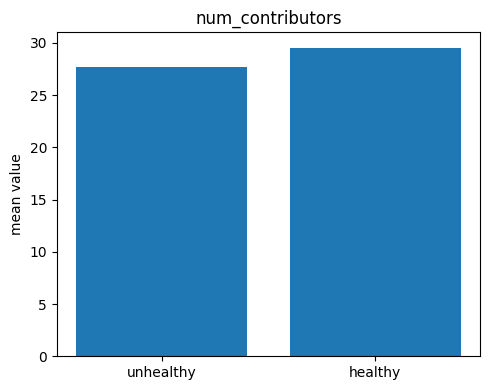

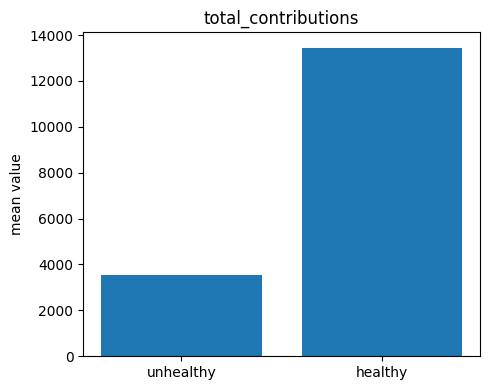

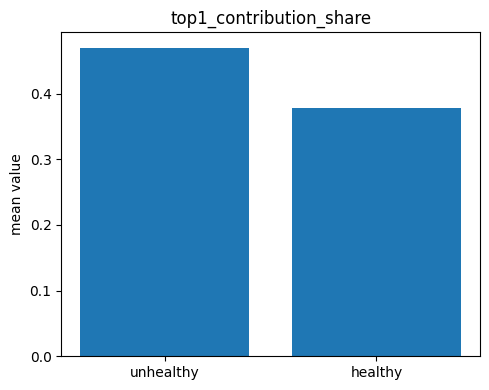

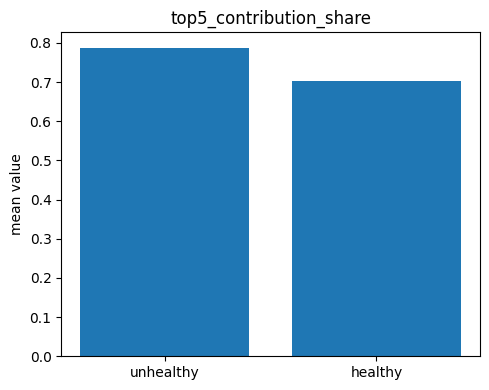

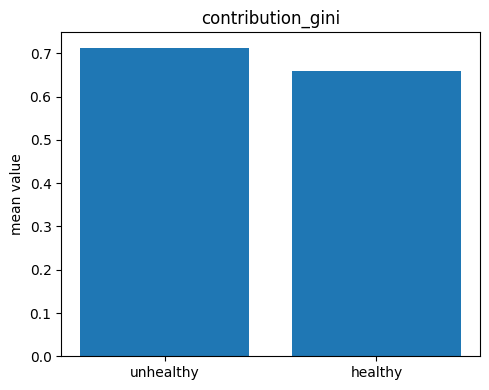

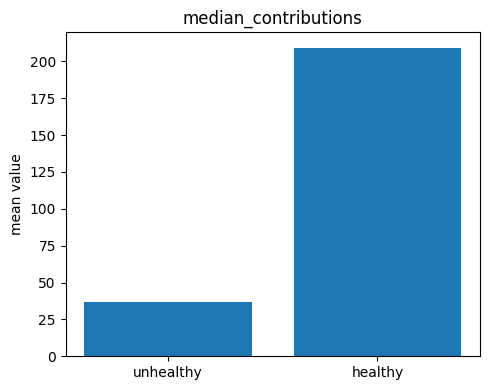

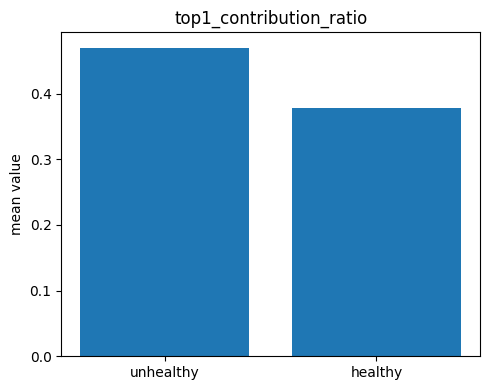

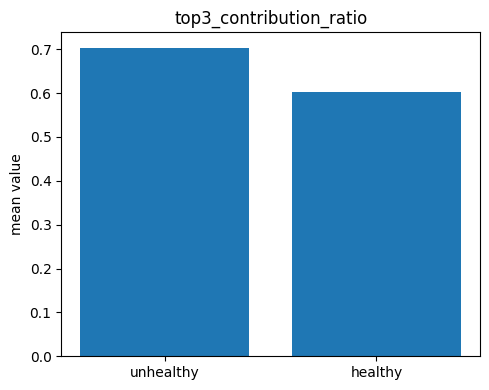

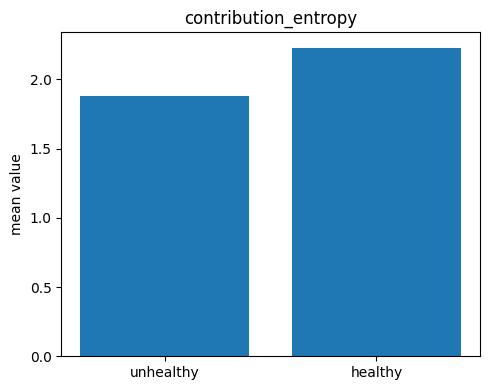

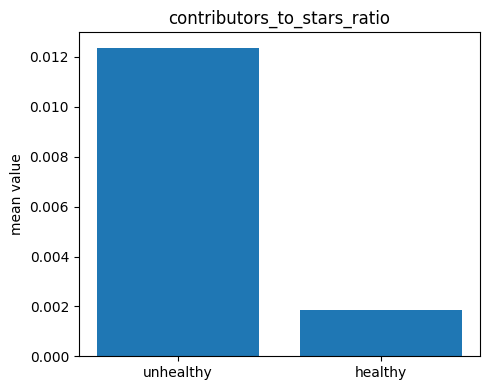

In [22]:
plot_df = summary[["unhealthy_mean", "healthy_mean"]].copy()

for feature in plot_df.index:
    plt.figure(figsize=(5, 4))
    values = plot_df.loc[feature]
    plt.bar(["unhealthy", "healthy"], values)
    plt.title(feature)
    plt.ylabel("mean value")
    plt.tight_layout()
    plt.show()

/var/folders/g8/gwqmqng10_g3h7m8r02yq1qc0000gn/T/ipykernel_35627/2533254159.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


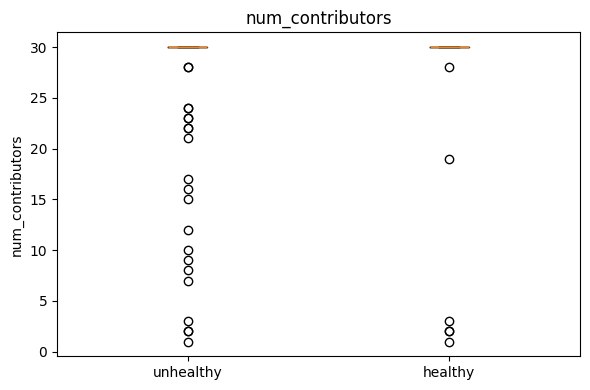

/var/folders/g8/gwqmqng10_g3h7m8r02yq1qc0000gn/T/ipykernel_35627/2533254159.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


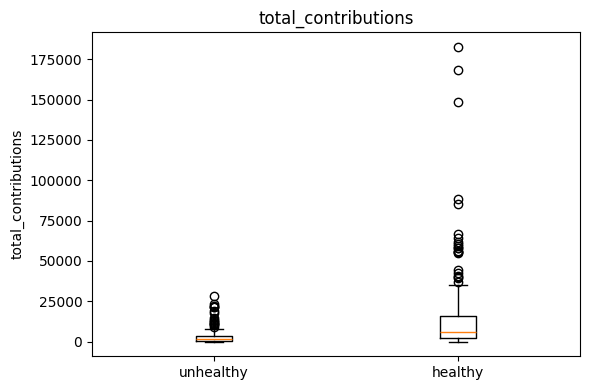

/var/folders/g8/gwqmqng10_g3h7m8r02yq1qc0000gn/T/ipykernel_35627/2533254159.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


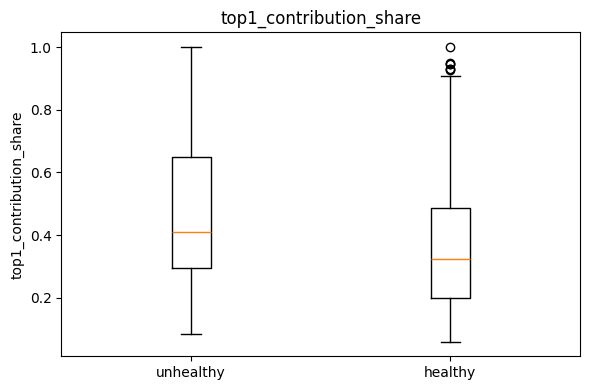

/var/folders/g8/gwqmqng10_g3h7m8r02yq1qc0000gn/T/ipykernel_35627/2533254159.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


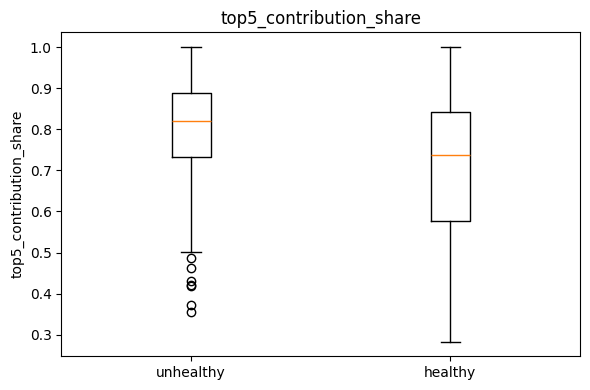

/var/folders/g8/gwqmqng10_g3h7m8r02yq1qc0000gn/T/ipykernel_35627/2533254159.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


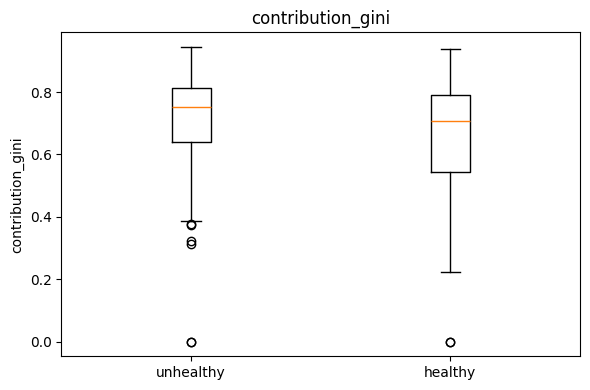

/var/folders/g8/gwqmqng10_g3h7m8r02yq1qc0000gn/T/ipykernel_35627/2533254159.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


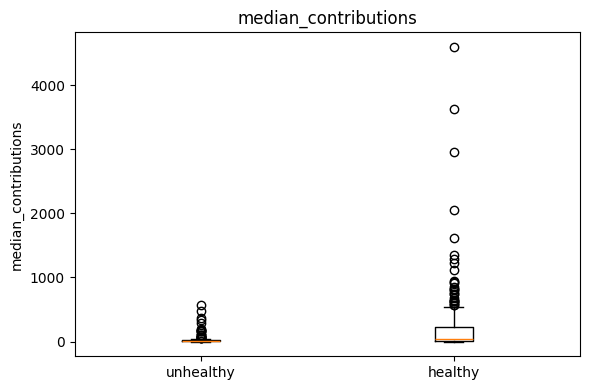

/var/folders/g8/gwqmqng10_g3h7m8r02yq1qc0000gn/T/ipykernel_35627/2533254159.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


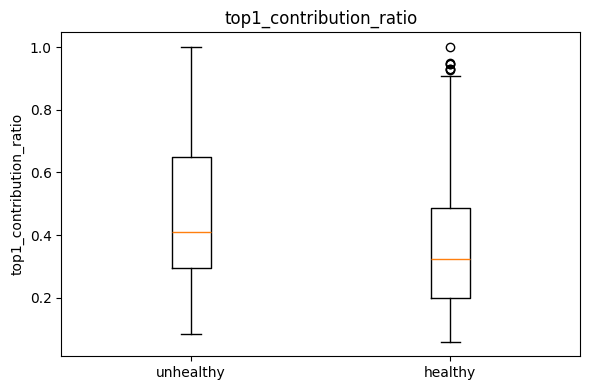

/var/folders/g8/gwqmqng10_g3h7m8r02yq1qc0000gn/T/ipykernel_35627/2533254159.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


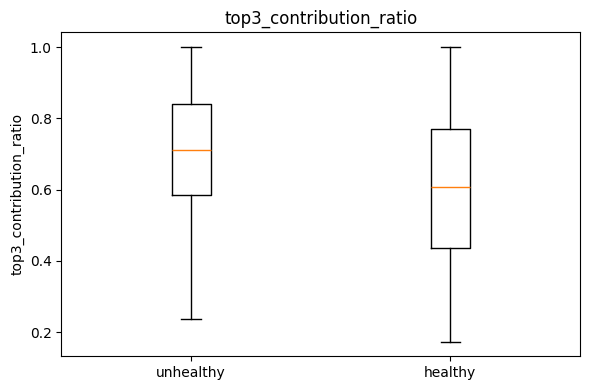

/var/folders/g8/gwqmqng10_g3h7m8r02yq1qc0000gn/T/ipykernel_35627/2533254159.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


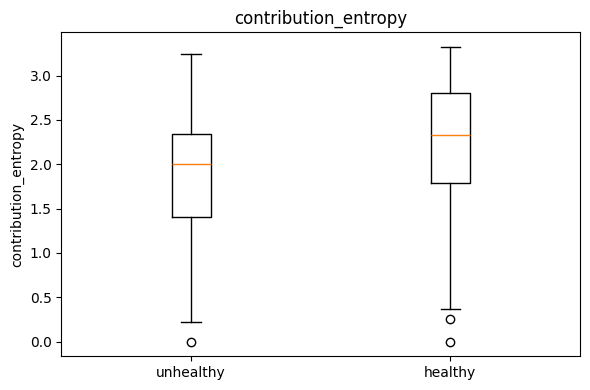

/var/folders/g8/gwqmqng10_g3h7m8r02yq1qc0000gn/T/ipykernel_35627/2533254159.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


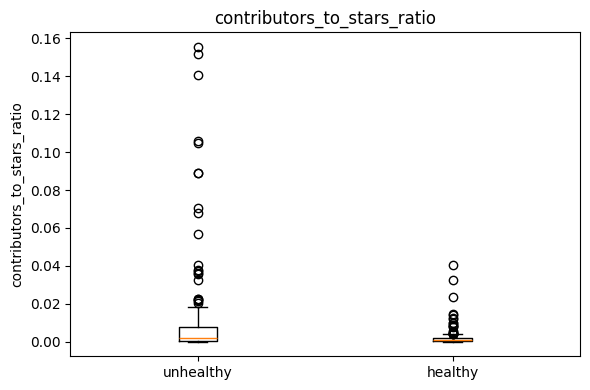

In [23]:
for feature in contributor_features:
    plt.figure(figsize=(6, 4))

    unhealthy_values = contributor_df.loc[
        contributor_df["label"] == 0, feature
    ].dropna()

    healthy_values = contributor_df.loc[
        contributor_df["label"] == 1, feature
    ].dropna()

    plt.boxplot(
        [unhealthy_values, healthy_values],
        labels=["unhealthy", "healthy"]
    )

    plt.title(feature)
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

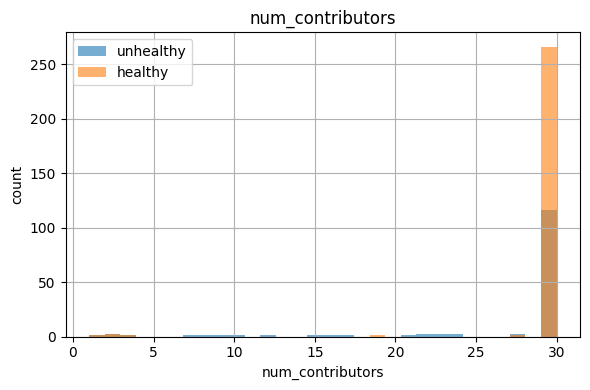

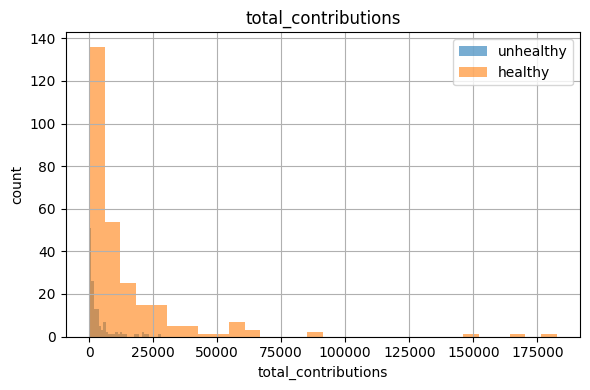

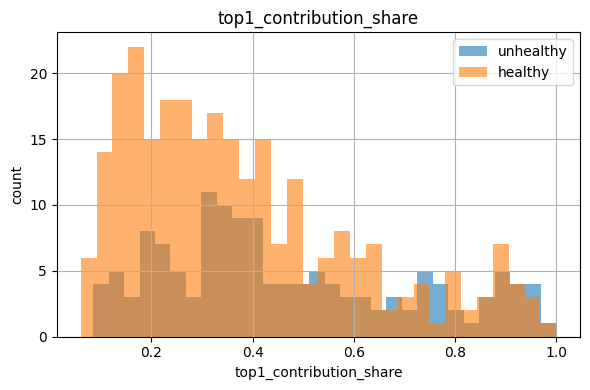

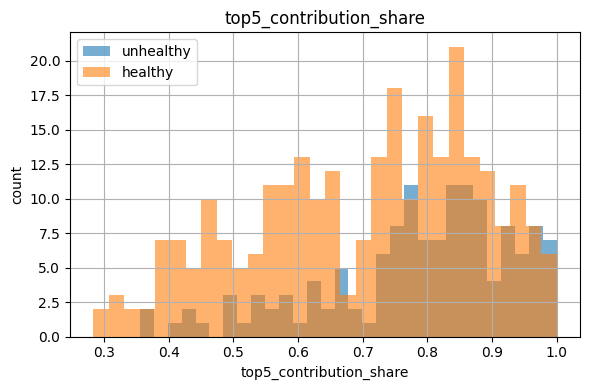

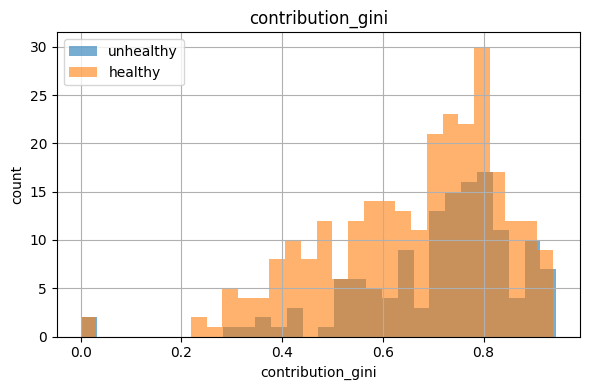

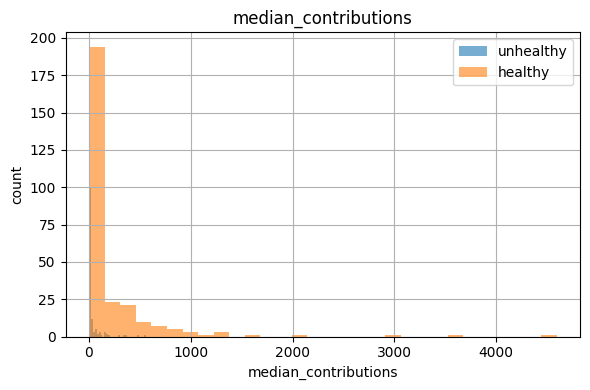

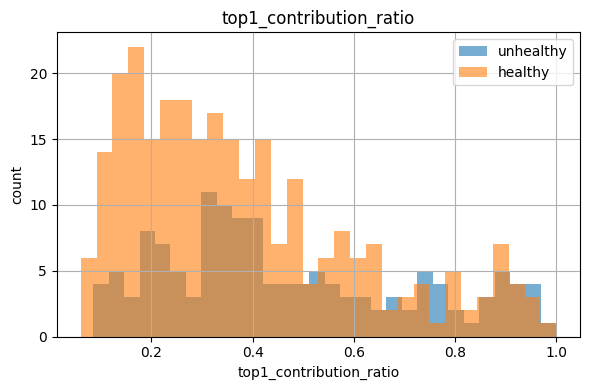

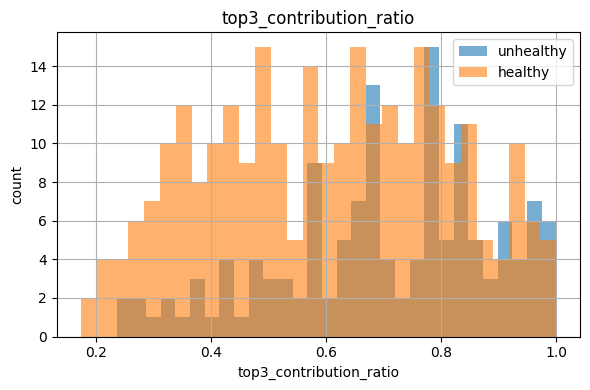

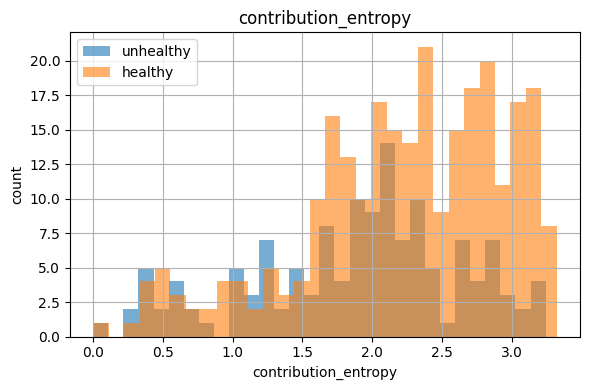

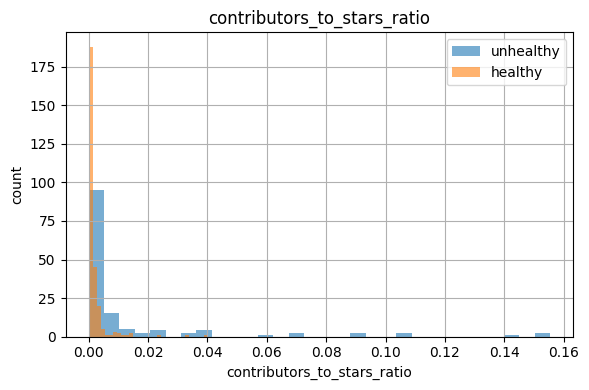

In [24]:
for feature in contributor_features:
    plt.figure(figsize=(6, 4))

    contributor_df.loc[
        contributor_df["label"] == 0, feature
    ].dropna().hist(alpha=0.6, bins=30, label="unhealthy")

    contributor_df.loc[
        contributor_df["label"] == 1, feature
    ].dropna().hist(alpha=0.6, bins=30, label="healthy")

    plt.title(feature)
    plt.xlabel(feature)
    plt.ylabel("count")
    plt.legend()
    plt.tight_layout()
    plt.show()

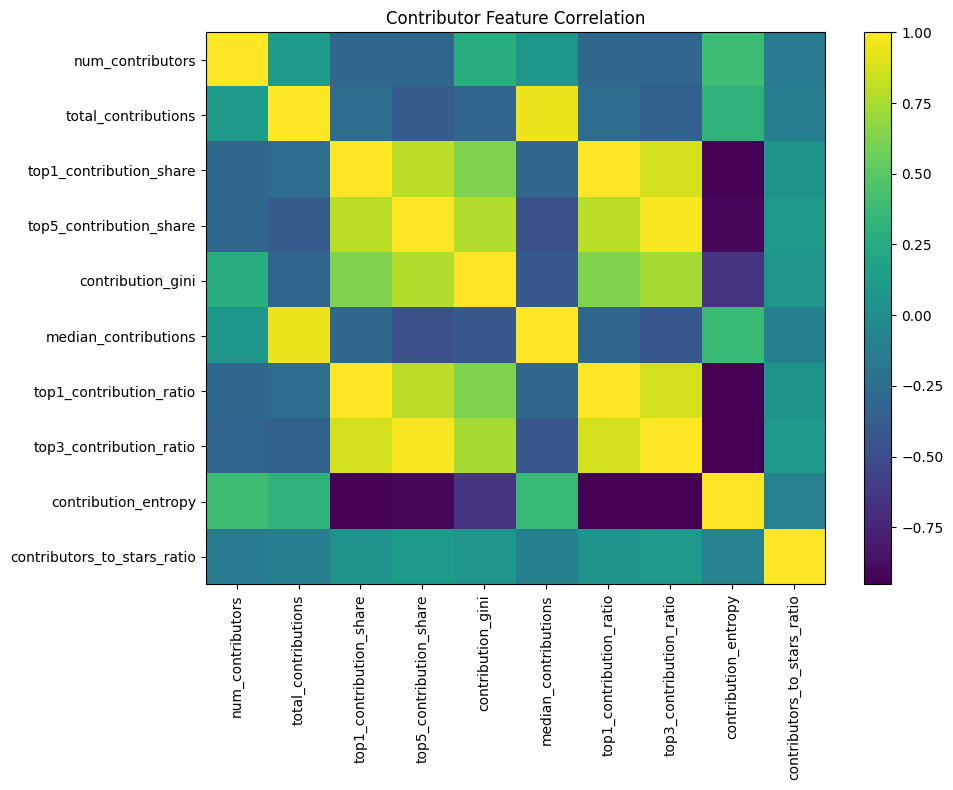

In [25]:
corr_df = contributor_df[contributor_features].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_df, aspect="auto")
plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=90)
plt.yticks(range(len(corr_df.index)), corr_df.index)
plt.colorbar()
plt.title("Contributor Feature Correlation")
plt.tight_layout()
plt.show()

In [26]:
summary.sort_values(
    by="mean_diff_healthy_minus_unhealthy",
    ascending=False
)

label,unhealthy_mean,healthy_mean,unhealthy_median,healthy_median,mean_diff_healthy_minus_unhealthy,median_diff_healthy_minus_unhealthy
total_contributions,3546.299270,13445.981618,1666.000000,6053.000000,9899.682348,4387.000000
median_contributions,37.105839,209.253676,7.500000,40.000000,172.147837,32.500000
num_contributors,27.715328,29.540441,30.000000,30.000000,1.825113,0.000000
contribution_entropy,1.878744,2.228391,2.008609,2.329305,0.349647,0.320696
contributors_to_stars_ratio,0.012369,0.001857,0.001853,0.000878,-0.010513,-0.000975
contribution_gini,0.713175,0.659995,0.751116,0.707673,-0.053180,-0.043443
top5_contribution_share,0.787410,0.702931,0.819277,0.738417,-0.084480,-0.080860
top1_contribution_share,0.469759,0.378415,0.408476,0.323672,-0.091344,-0.084805
top1_contribution_ratio,0.469759,0.378415,0.408476,0.323672,-0.091344,-0.084805
top3_contribution_ratio,0.703278,0.602344,0.711316,0.608311,-0.100934,-0.103005


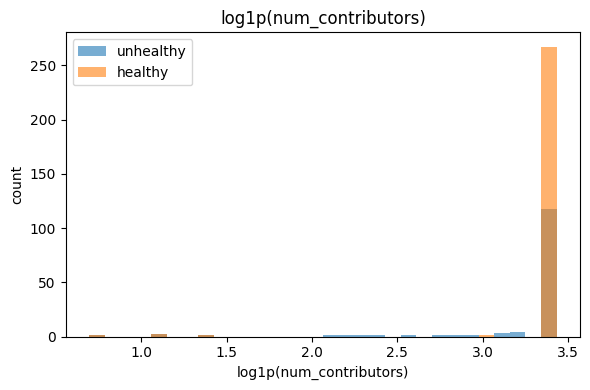

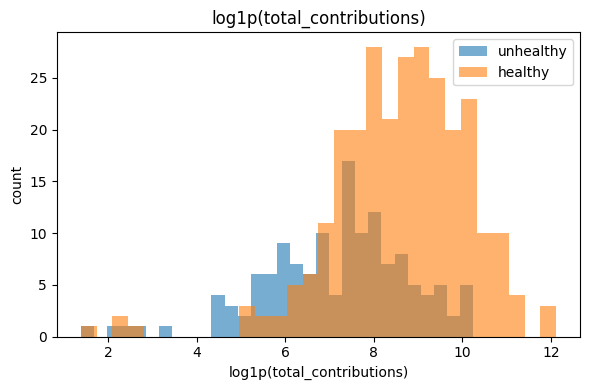

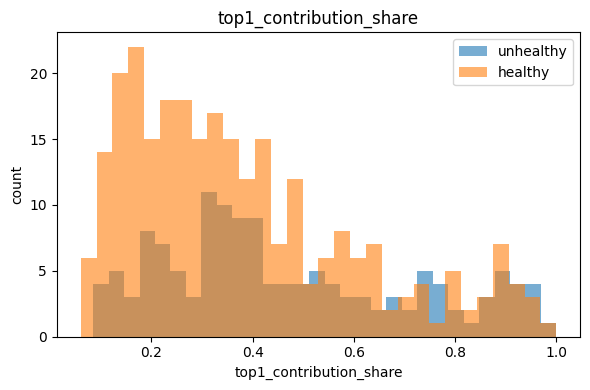

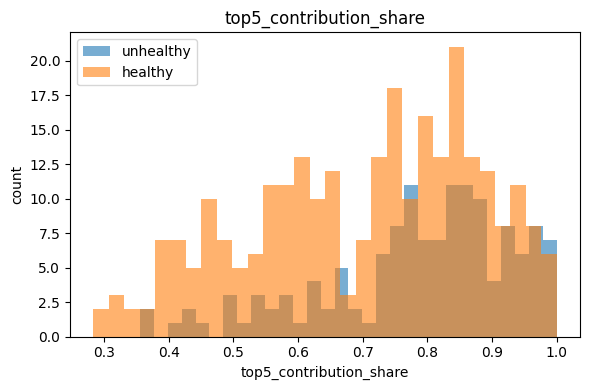

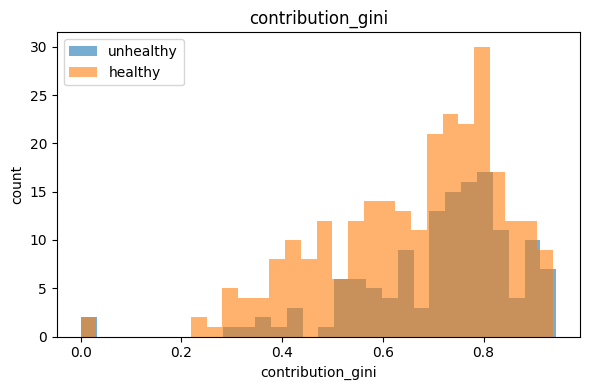

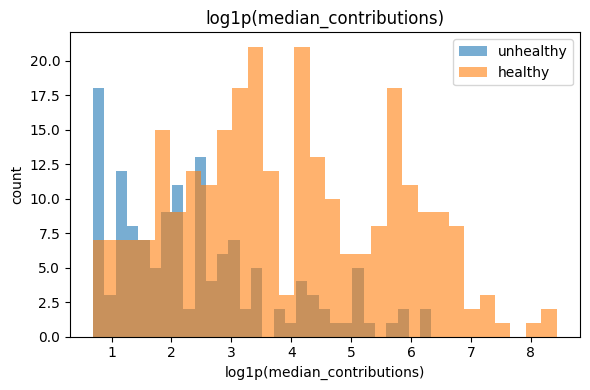

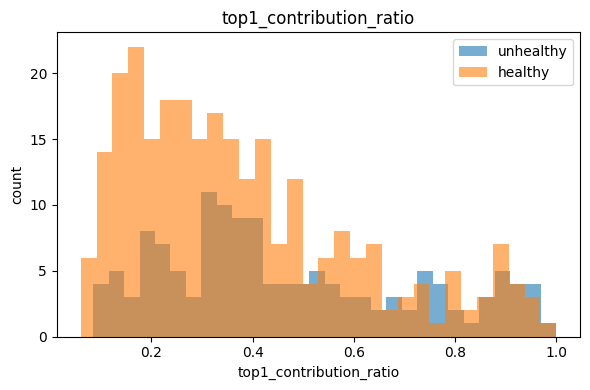

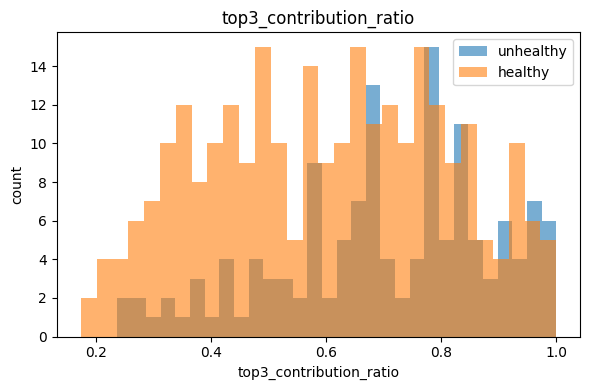

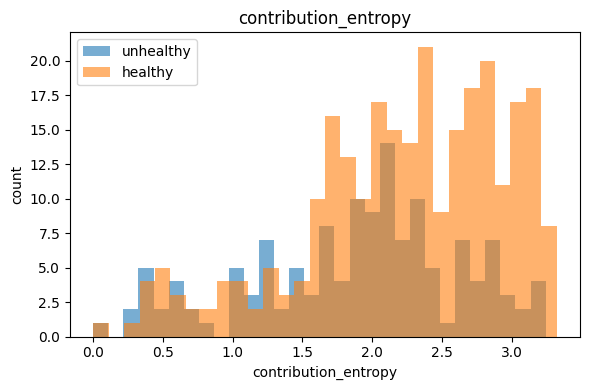

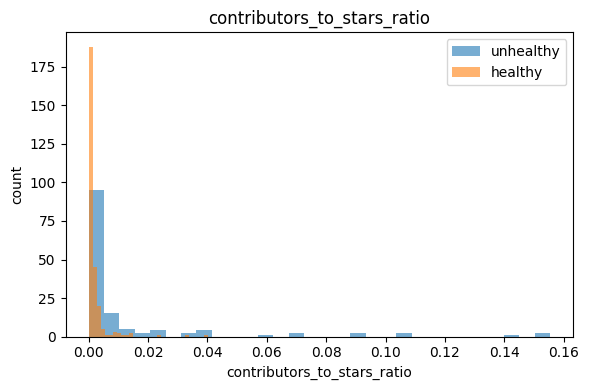

In [27]:
import numpy as np
import matplotlib.pyplot as plt

log_transform_features = [
    "total_contributions",
    "median_contributions",
    "num_contributors",
]

for feature in contributor_features:
    plt.figure(figsize=(6, 4))

    unhealthy_data = contributor_df.loc[
        contributor_df["label"] == 0, feature
    ].dropna()

    healthy_data = contributor_df.loc[
        contributor_df["label"] == 1, feature
    ].dropna()

    if feature in log_transform_features:
        unhealthy_data = np.log1p(unhealthy_data)
        healthy_data = np.log1p(healthy_data)

    plt.hist(
        unhealthy_data,
        bins=30,
        alpha=0.6,
        label="unhealthy"
    )

    plt.hist(
        healthy_data,
        bins=30,
        alpha=0.6,
        label="healthy"
    )

    if feature in log_transform_features:
        plt.title(f"log1p({feature})")
        plt.xlabel(f"log1p({feature})")
    else:
        plt.title(feature)
        plt.xlabel(feature)

    plt.ylabel("count")
    plt.legend()
    plt.tight_layout()
    plt.show()

Contributor Feature Analysis

Contributor feature 분석 결과, healthy repository는 단순히 contribution 규모만 큰 것이 아니라 contributor participation이 더 분산되고 collaborative structure가 안정적인 특징을 보였다.

주요 결과 요약

| Feature                           | Healthy 특징 | 해석                                     |
| --------------------------------- | ---------- | -------------------------------------- |
| total_contributions               | 매우 높음      | 전체 활동량이 큼                              |
| median_contributions              | 높음         | 특정 일부가 아닌 전반적 contributor activity가 높음 |
| num_contributors                  | 큰 차이 없음    | contributor 수 자체보다 구조가 중요              |
| top1/top3/top5 contribution share | 낮음         | 특정 maintainer 의존도가 낮음                  |
| contribution_gini                 | 낮음         | contribution 불균형이 상대적으로 적음             |
| contribution_entropy              | 높음         | contributor 다양성과 협업 분산 구조가 큼           |
| contributors_to_stars_ratio       | 낮음         | popularity 대비 contributor 효율 구조 차이 가능성 |

기여 활동 규모(Activity Scale)

Healthy repository는 contribution 규모 자체가 unhealthy repository보다 크게 나타났다.

| Feature                     | unhealthy | healthy |
| --------------------------- | --------: | ------: |
| total_contributions mean    |     3,546 |  13,445 |
| total_contributions median  |     1,666 |   6,053 |
| median_contributions mean   |      37.1 |   209.3 |
| median_contributions median |       7.5 |    40.0 |

특히 median 값에서도 큰 차이가 유지되었기 때문에, 단순히 몇 개의 초대형 repository가 평균을 끌어올린 현상이 아니라 전반적인 contributor ecosystem 차이가 존재함을 확인할 수 있었다.

로그 변환(log1p) 분석

OSS contribution 데이터는 long-tail distribution 특성을 가지므로 다음 feature에 대해 log1p transformation을 수행하였다.

* total_contributions
* median_contributions

로그 변환 이후에도 healthy repository 분포가 전체적으로 오른쪽으로 이동한 형태를 유지하였다.

해석:

* healthy repository의 높은 activity는 일부 outlier 때문만이 아니라 구조적 차이임
* contributor ecosystem 전체가 더 활발하게 유지됨

Contributor Concentration 분석

Healthy repository는 contribution concentration이 더 낮게 나타났다.

| Feature                 | unhealthy mean | healthy mean |
| ----------------------- | -------------: | -----------: |
| top1_contribution_share |          0.470 |        0.378 |
| top3_contribution_ratio |          0.703 |        0.602 |
| top5_contribution_share |          0.787 |        0.703 |
| contribution_gini       |          0.713 |        0.660 |

의미:

* unhealthy repository는 일부 핵심 maintainer에게 contribution이 집중되는 경향
* maintainer dependency 및 bus factor risk 가능성 존재
* healthy repository는 contribution이 여러 contributor에게 분산됨

Contribution Diversity 분석

| Feature                   | unhealthy | healthy |
| ------------------------- | --------: | ------: |
| contribution_entropy mean |     1.879 |   2.228 |

Healthy repository는 더 높은 entropy를 보였다.

이는:

* contributor participation diversity 증가
* collaborative ecosystem 활성화
* 특정 contributor 의존성 감소

를 의미한다.

Correlation Structure 분석

Correlation heatmap에서는 contributor concentration 관련 feature들이 강한 양의 상관관계를 형성하였다.

Strong correlation cluster:

* top1_contribution_share
* top3_contribution_ratio
* top5_contribution_share
* contribution_gini

반면 contribution_entropy는 이들과 강한 음의 상관관계를 보였다.

해석:

* OSS repository health는 단순 activity 규모보다
  “Contribution Concentration ↔ Collaboration Diversity”
  축에서 설명될 가능성이 큼
* contributor ecosystem의 분산 구조가 repository health와 밀접하게 연결됨

최종 해석

> Healthy OSS repository는 단순히 contributor 수가 많은 것이 아니라:
>
> * contribution activity 규모가 크고
> * contributor participation이 분산되어 있으며
> * 특정 maintainer 의존도가 낮고
> * collaborative structure가 안정적이라는 특징을 가진다.
>
> 반대로 unhealthy repository는:
>
> * contribution concentration이 높고
> * 일부 contributor 의존성이 강하며
> * ecosystem 다양성이 낮은 구조를 보였다.


---

## **2. Deployment / Release Maturity**

**의미**

“실제로 운영·배포되는 OSS인가”

**핵심 질문**
- release 체계가 안정적인가?
- semantic versioning 잘 지키는가?
- deployment 활동이 존재하는가?

| 컬럼명                          | 의미                                   | 해석                            |
| ---------------------------- | ------------------------------------ | ----------------------------- |
| `num_deployments`            | deployment 기록 수                      | 실제 운영·배포 활동 빈도를 의미            |
| `has_deployments`            | deployment 존재 여부                     | CI/CD 또는 운영 환경 사용 여부를 나타냄     |
| `num_unique_refs`            | deployment에 사용된 고유 ref(branch/tag) 수 | 다양한 release/version 운영 여부를 의미 |
| `tag_based_deployment_ratio` | tag 기반 deployment 비율                 | 정식 release 중심 운영 여부를 나타냄      |
| `deployment_recency_days`    | 마지막 deployment 이후 경과 일수              | 최근까지 운영·배포가 유지되는지 반영          |
| `num_tags`                   | 전체 tag 수                             | release/version 관리 활동 규모를 의미  |
| `stable_tag_ratio`           | stable release tag 비율                | 안정 버전 중심 release 구조 여부를 나타냄   |
| `prerelease_tag_ratio`       | prerelease(alpha/beta/rc) tag 비율     | 실험적·개발 단계 release 비중을 의미      |
| `latest_tag_is_stable`       | 최신 tag가 stable 여부                    | 현재 release 상태가 안정 버전인지 나타냄    |
| `latest_tag_is_prerelease`   | 최신 tag가 prerelease 여부                | 현재 개발·실험 단계 release인지 반영      |
| `semver_tag_ratio`           | semantic versioning 규칙을 따르는 tag 비율   | 체계적인 버전 관리 수준을 의미             |
| `num_major_versions`         | major version 수                      | 장기적인 프로젝트 진화·확장 정도를 나타냄       |
| `num_minor_versions`         | minor version 수                      | 세부 기능 업데이트 및 유지보수 빈도를 의미      |
| `tag_release_velocity`       | 단위 시간당 tag 생성 속도                     | release/update 주기의 활발함을 의미    |


In [14]:
release_features = [
    "num_deployments",
    "has_deployments",
    "num_unique_refs",
    "tag_based_deployment_ratio",
    "deployment_recency_days",
    "num_tags",
    "stable_tag_ratio",
    "prerelease_tag_ratio",
    "latest_tag_is_stable",
    "latest_tag_is_prerelease",
    "semver_tag_ratio",
    "num_major_versions",
    "num_minor_versions",
    "tag_release_velocity",
]

In [28]:
release_df = df[release_features + ["label"]].copy()

for col in release_features:
    release_df[col] = pd.to_numeric(
        release_df[col],
        errors="coerce"
    )

summary_mean = (
    release_df
    .groupby("label")[release_features]
    .mean()
    .T
)

summary_median = (
    release_df
    .groupby("label")[release_features]
    .median()
    .T
)

summary = pd.concat(
    [
        summary_mean.rename(
            columns={
                0: "unhealthy_mean",
                1: "healthy_mean"
            }
        ),
        summary_median.rename(
            columns={
                0: "unhealthy_median",
                1: "healthy_median"
            }
        ),
    ],
    axis=1
)

summary["mean_diff_healthy_minus_unhealthy"] = (
    summary["healthy_mean"]
    - summary["unhealthy_mean"]
)

summary["median_diff_healthy_minus_unhealthy"] = (
    summary["healthy_median"]
    - summary["unhealthy_median"]
)

summary

label,unhealthy_mean,healthy_mean,unhealthy_median,healthy_median,mean_diff_healthy_minus_unhealthy,median_diff_healthy_minus_unhealthy
num_deployments,9.598540,15.602941,0.000000,20.000000,6.004401,20.000000
has_deployments,0.401460,0.610294,0.000000,1.000000,0.208834,1.000000
num_unique_refs,4.445255,7.014706,0.000000,1.000000,2.569450,1.000000
tag_based_deployment_ratio,0.021898,0.063509,0.000000,0.000000,0.041611,0.000000
deployment_recency_days,388.132897,341.474305,0.000000,0.232074,-46.658592,0.232074
num_tags,17.452555,25.161765,27.000000,30.000000,7.709210,3.000000
stable_tag_ratio,0.434814,0.566090,0.300000,0.700000,0.131276,0.400000
prerelease_tag_ratio,0.119535,0.153006,0.000000,0.000000,0.033471,0.000000
latest_tag_is_stable,0.445255,0.540441,0.000000,1.000000,0.095186,1.000000
latest_tag_is_prerelease,0.058394,0.136029,0.000000,0.000000,0.077635,0.000000


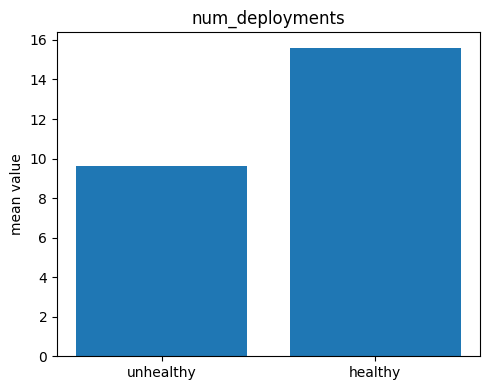

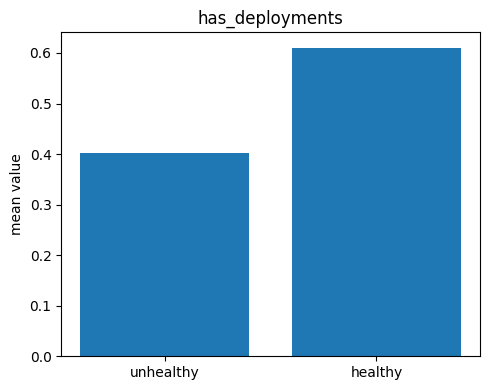

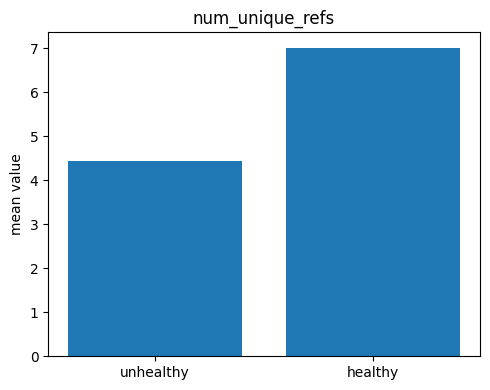

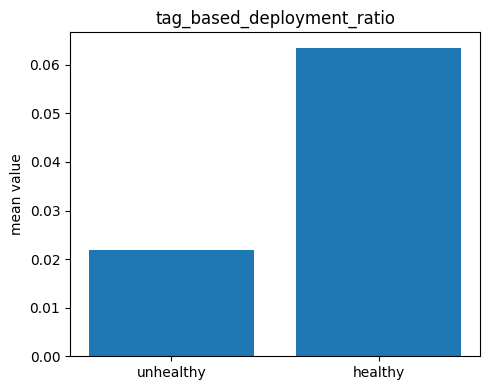

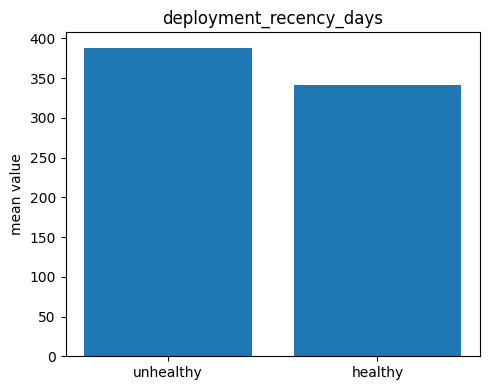

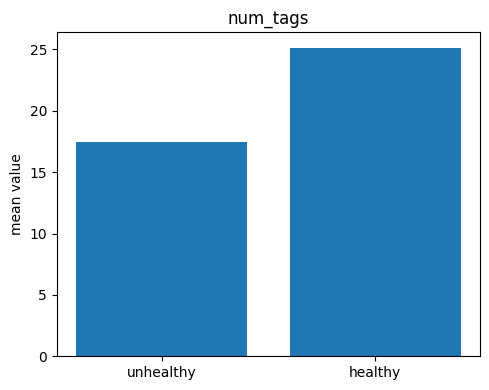

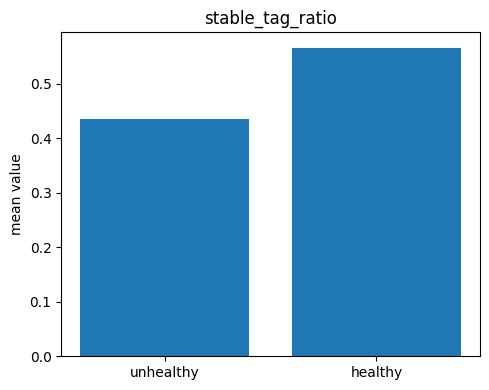

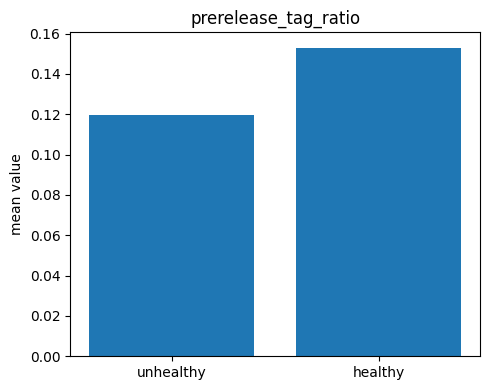

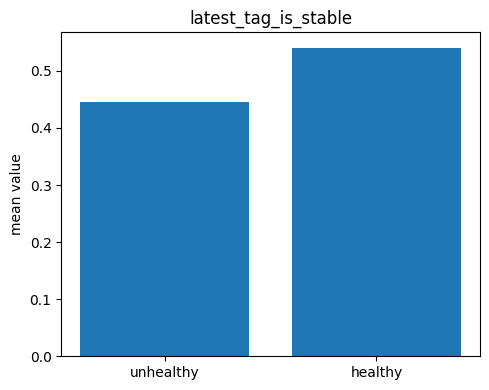

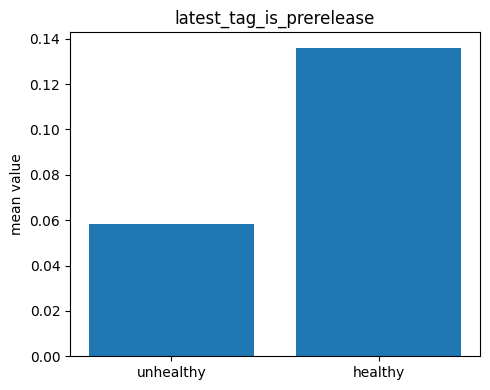

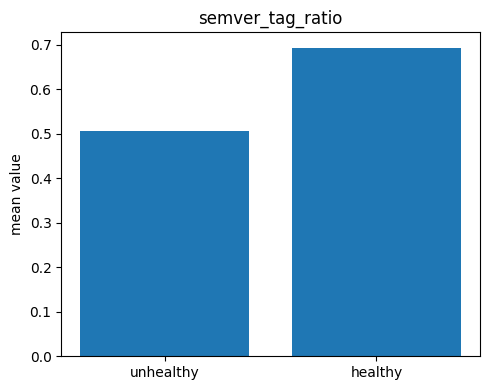

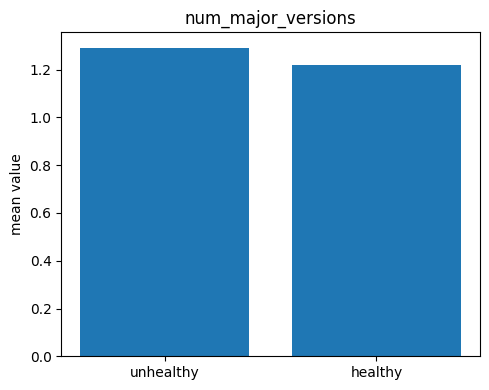

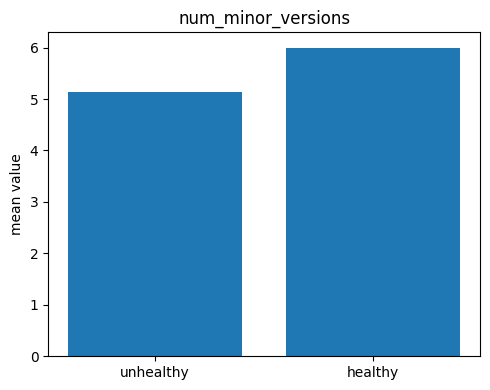

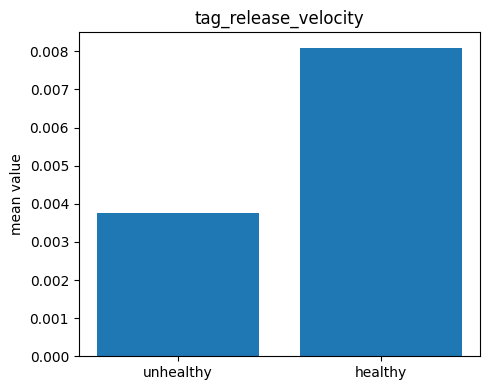

In [29]:
plot_df = summary[
    ["unhealthy_mean", "healthy_mean"]
].copy()

for feature in plot_df.index:

    plt.figure(figsize=(5, 4))

    values = plot_df.loc[feature]

    plt.bar(
        ["unhealthy", "healthy"],
        values
    )

    plt.title(feature)
    plt.ylabel("mean value")

    plt.tight_layout()
    plt.show()


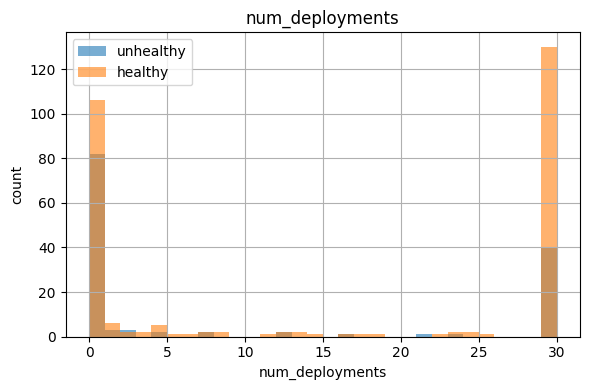

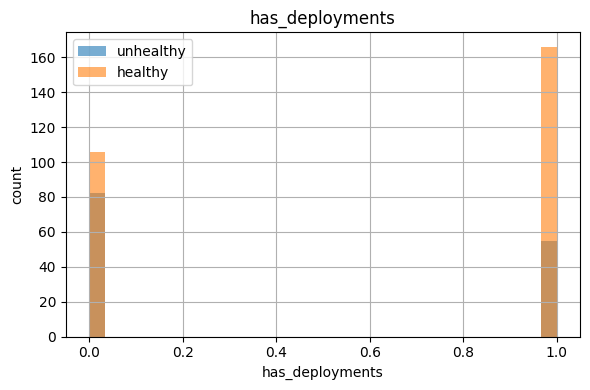

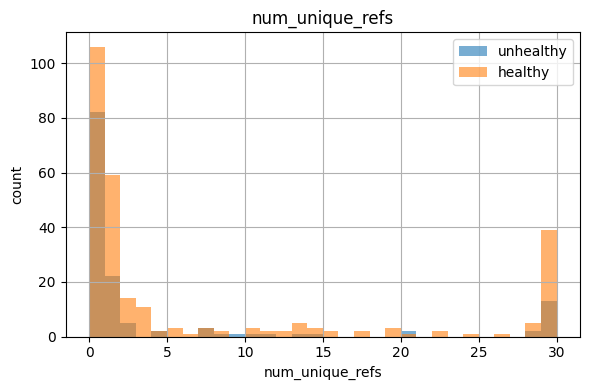

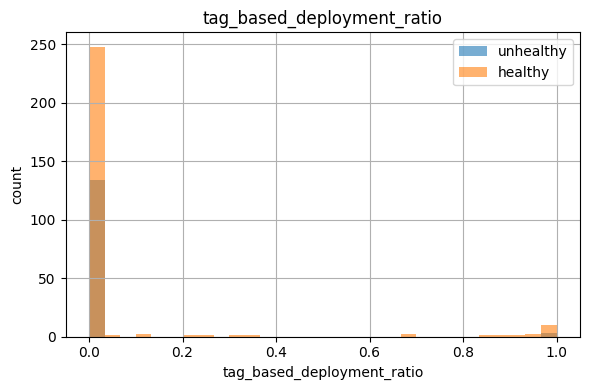

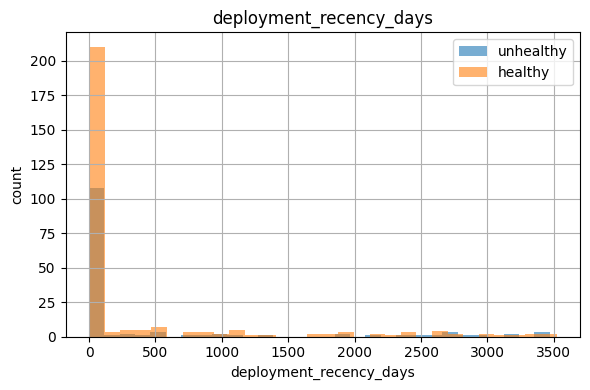

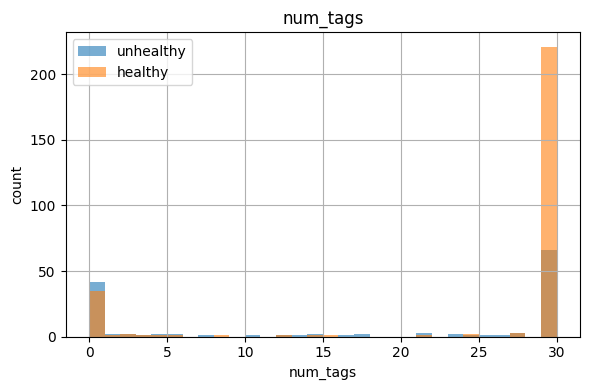

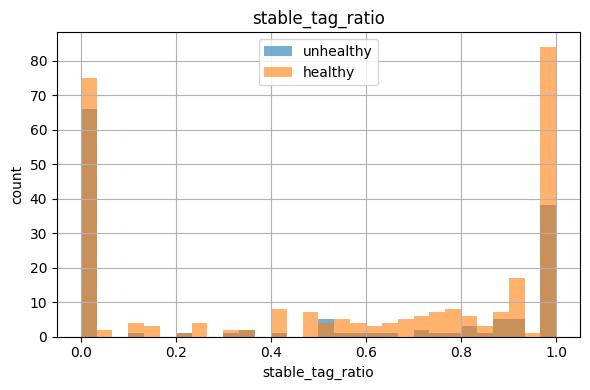

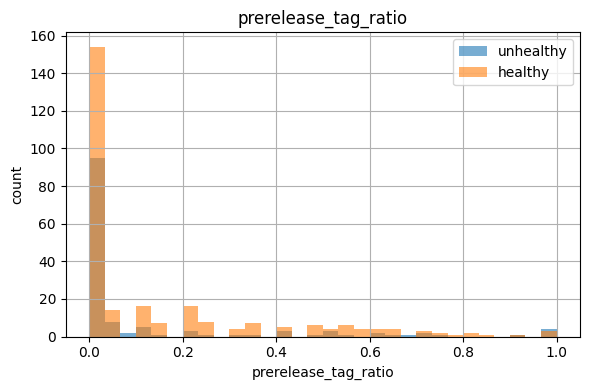

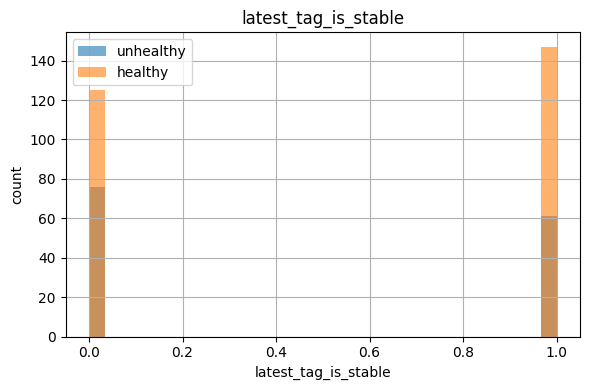

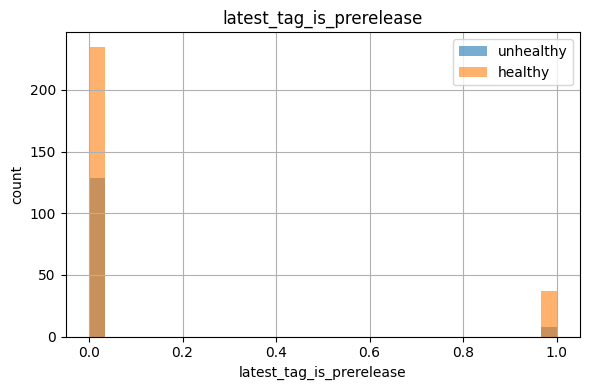

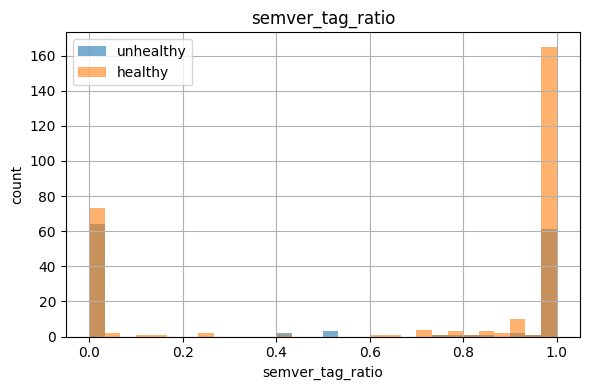

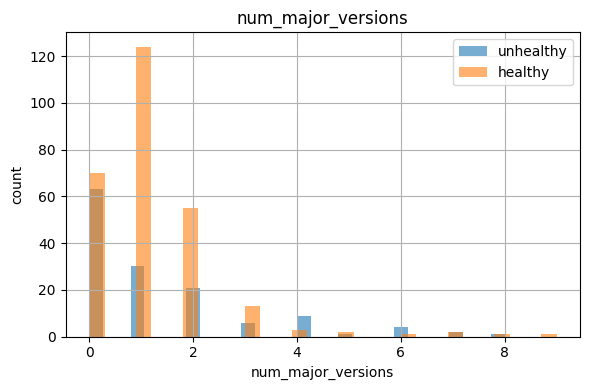

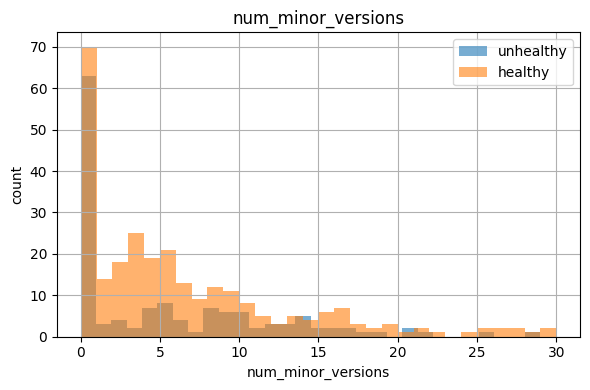

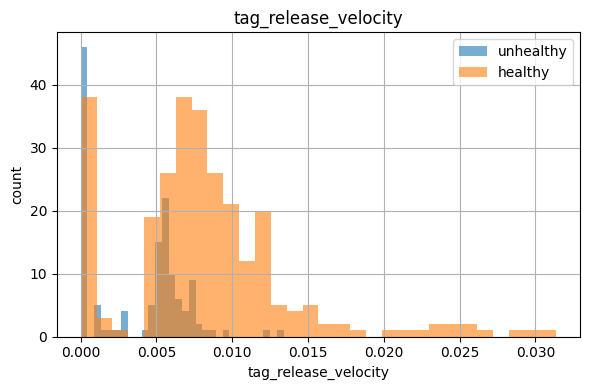

In [30]:
for feature in release_features:

    plt.figure(figsize=(6, 4))

    (
        release_df.loc[
            release_df["label"] == 0,
            feature
        ]
        .dropna()
        .hist(
            alpha=0.6,
            bins=30,
            label="unhealthy"
        )
    )

    (
        release_df.loc[
            release_df["label"] == 1,
            feature
        ]
        .dropna()
        .hist(
            alpha=0.6,
            bins=30,
            label="healthy"
        )
    )

    plt.title(feature)
    plt.xlabel(feature)
    plt.ylabel("count")

    plt.legend()

    plt.tight_layout()
    plt.show()

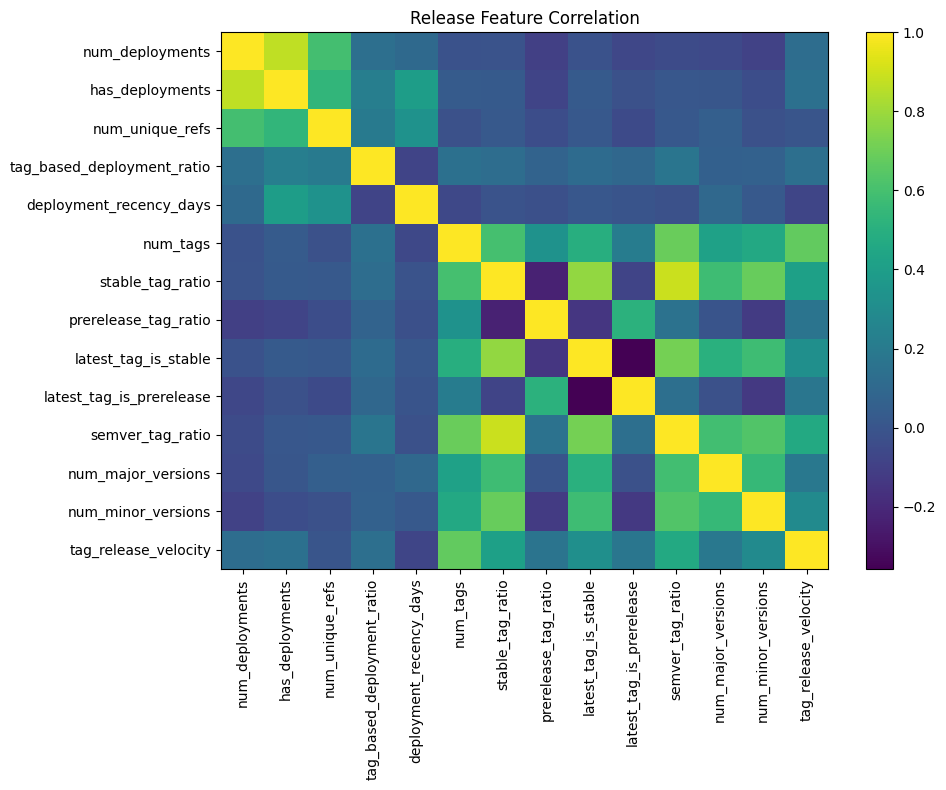

In [32]:
corr_df = (
    release_df[release_features]
    .corr()
)

plt.figure(figsize=(10, 8))

plt.imshow(
    corr_df,
    aspect="auto"
)

plt.xticks(
    range(len(corr_df.columns)),
    corr_df.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_df.index)),
    corr_df.index
)

plt.colorbar()

plt.title("Release Feature Correlation")

plt.tight_layout()
plt.show()

In [33]:
summary.sort_values(
    by="mean_diff_healthy_minus_unhealthy",
    ascending=False
)

label,unhealthy_mean,healthy_mean,unhealthy_median,healthy_median,mean_diff_healthy_minus_unhealthy,median_diff_healthy_minus_unhealthy
num_tags,17.452555,25.161765,27.000000,30.000000,7.709210,3.000000
num_deployments,9.598540,15.602941,0.000000,20.000000,6.004401,20.000000
num_unique_refs,4.445255,7.014706,0.000000,1.000000,2.569450,1.000000
num_minor_versions,5.145985,5.996324,2.000000,4.000000,0.850338,2.000000
has_deployments,0.401460,0.610294,0.000000,1.000000,0.208834,1.000000
semver_tag_ratio,0.504984,0.692993,0.529412,1.000000,0.188009,0.470588
stable_tag_ratio,0.434814,0.566090,0.300000,0.700000,0.131276,0.400000
latest_tag_is_stable,0.445255,0.540441,0.000000,1.000000,0.095186,1.000000
latest_tag_is_prerelease,0.058394,0.136029,0.000000,0.000000,0.077635,0.000000
tag_based_deployment_ratio,0.021898,0.063509,0.000000,0.000000,0.041611,0.000000


Release / Deployment Feature 분석

핵심 결과

Healthy repository는 전반적으로 deployment 활동과 release 관리 체계가 더 활발하게 나타났다. 특히 semantic versioning 사용 비율, stable release 비율, deployment 존재 여부, release 생성 속도(tag_release_velocity) 등에서 healthy repository가 더 높은 값을 보였다. 반면 unhealthy repository는 deployment 자체가 존재하지 않는 경우가 많았으며, release/tag 관리 또한 상대적으로 불규칙한 경향을 보였다.

주요 feature별 비교

| Feature                   | Healthy 특징               | 해석                           |
| ------------------------- | ------------------------ | ---------------------------- |
| `num_tags`                | 평균 및 중앙값 모두 더 높음         | 장기간 release/version 관리가 더 활발 |
| `num_deployments`         | 중앙값 차이가 매우 큼 (20 vs 0)   | 실제 운영·배포 활동 존재 가능성           |
| `num_unique_refs`         | 더 높음                     | 다양한 branch/tag 기반 운영         |
| `has_deployments`         | deployment 존재 비율 높음      | CI/CD 및 운영 maturity 반영       |
| `semver_tag_ratio`        | 큰 차이 존재                  | 체계적인 semantic versioning 사용  |
| `stable_tag_ratio`        | healthy에서 높음             | 안정 release 중심 운영             |
| `latest_tag_is_stable`    | healthy에서 더 높음           | 최근 release 안정성 유지            |
| `tag_release_velocity`    | healthy가 약 2배 수준         | release/update 주기 활발         |
| `deployment_recency_days` | healthy가 더 최근 deployment | 최근까지 운영 활동 유지 가능성            |

`tag_release_velocity` 분석

히스토그램 결과 unhealthy repository는 대부분 0 근처에 밀집되어 있었으며, healthy repository는 더 넓은 분포를 가지면서 높은 값 영역까지 확장되는 경향을 보였다. 이는 healthy repository가 지속적으로 새로운 release/tag를 생성하는 경향이 강하다는 점을 의미한다. 반면 unhealthy repository는 release 생성 자체가 드물거나 maintenance가 정체된 상태인 경우가 많았다.

Correlation 분석

`stable_tag_ratio`, `semver_tag_ratio`, `latest_tag_is_stable`, `num_minor_versions`, `tag_release_velocity` 사이에는 강한 양의 상관관계가 나타났다. 이는 semantic versioning 기반의 안정적인 release 관리 구조와 지속적인 업데이트 체계가 함께 나타나는 경향을 의미한다.

또한 `num_deployments`, `has_deployments`, `num_unique_refs` 간에도 높은 상관관계가 나타났는데, deployment를 적극적으로 사용하는 프로젝트일수록 다양한 ref/tag 기반 운영 구조를 가지고 있을 가능성이 높다는 점을 보여준다.

반면 `stable_tag_ratio`와 `prerelease_tag_ratio` 사이에는 강한 음의 상관관계가 나타났다. 이는 stable release 중심 프로젝트일수록 prerelease 비율이 낮고, experimental/testing 중심 프로젝트일수록 stable release 비율이 낮아지는 자연스러운 구조를 반영한다.

해석 요약

이번 release/deployment feature 분석 결과 healthy OSS는 단순히 인기 있는 프로젝트가 아니라 실제 운영 가능한 release lifecycle과 deployment maturity를 가진 프로젝트라는 점이 확인되었다. 특히 semantic versioning 사용, stable release 유지, 지속적인 deployment 활동, 빠른 release cycle 등이 healthy repository의 중요한 특성으로 나타났다.


## **3. Activity / Event Dynamics**

**의미**

“프로젝트가 실제로 살아 움직이는가”

**핵심 질문**
- interaction 활발한가?
- 개발 이벤트 중심인가?
- 단순 인기 repo인가?

| 컬럼명                             | 의미                                 | 해석                           |
| ------------------------------- | ---------------------------------- | ---------------------------- |
| `num_events`                    | 전체 GitHub event 수                  | 프로젝트 활동량 및 사용자 반응 규모를 의미     |
| `num_unique_event_types`        | 등장한 event 종류 수                     | 프로젝트 활동 유형의 다양성을 나타냄         |
| `dominant_event_ratio`          | 가장 많이 발생한 event 유형의 비율             | 특정 활동 유형에 편중된 정도를 의미         |
| `event_type_entropy`            | event 유형 분포의 entropy               | 활동 구조의 다양성과 균형 정도를 나타냄       |
| `has_IssuesEvent`               | IssuesEvent 존재 여부                  | issue 생성·관리 활동 존재 여부를 의미     |
| `has_PullRequestEvent`          | PullRequestEvent 존재 여부             | PR 기반 협업 개발 활동 존재 여부를 의미     |
| `has_IssueCommentEvent`         | IssueCommentEvent 존재 여부            | issue 토론 및 커뮤니케이션 활동 여부를 나타냄 |
| `recent_event_density`          | 최근 event 발생 밀도                     | 최근까지 프로젝트 활동이 유지되는 정도를 의미    |
| `IssuesEvent_ratio`             | 전체 event 중 IssuesEvent 비율          | issue 기반 관리 활동 비중을 나타냄       |
| `IssueCommentEvent_ratio`       | 전체 event 중 IssueCommentEvent 비율    | 커뮤니케이션·토론 활동 비중을 의미          |
| `PullRequestEvent_ratio`        | 전체 event 중 PullRequestEvent 비율     | 협업 기반 코드 기여 활동 비중을 의미        |
| `PushEvent_ratio`               | 전체 event 중 PushEvent 비율            | 실제 코드 업데이트 활동 비중을 의미         |
| `WatchEvent_ratio`              | 전체 event 중 WatchEvent 비율           | 사용자 관심·구독 활동 비중을 의미          |
| `ForkEvent_ratio`               | 전체 event 중 ForkEvent 비율            | 프로젝트 재사용·파생 개발 관심도를 나타냄      |
| `interaction_ratio`             | 상호작용(event 기반 communication) 관련 비율 | 사용자·개발자 간 커뮤니티 상호작용 수준을 의미   |
| `development_ratio`             | 개발 활동 중심 event 비율                  | 실제 코드 개발·유지보수 활동 중심성을 의미     |
| `external_interest_event_ratio` | 외부 관심 기반 event 비율                  | 사용자 관심·인기 중심 활동 비중을 나타냄      |


In [15]:
event_features = [
    "num_events",
    "num_unique_event_types",
    "dominant_event_ratio",
    "event_type_entropy",
    "has_IssuesEvent",
    "has_PullRequestEvent",
    "has_IssueCommentEvent",
    "recent_event_density",
    "IssuesEvent_ratio",
    "IssueCommentEvent_ratio",
    "PullRequestEvent_ratio",
    "PushEvent_ratio",
    "WatchEvent_ratio",
    "ForkEvent_ratio",
    "interaction_ratio",
    "development_ratio",
    "external_interest_event_ratio",
]

## **4. Popularity / Ecosystem Interest**

**의미**

“얼마나 주목받는가”

**핵심 질문**
- popularity와 health는 같은가?
- star inflation 존재하는가?

In [16]:
popularity_features = [
    "stargazers_count",
    "subscribers_count",
    "subscribers_to_stars_ratio",
    "forks_count",
    "network_count",
    "forks_to_stars_ratio",
    "open_issues_to_stars_ratio",
    "stars_per_repo_age_day",
    "forks_per_repo_age_day",
    "stars_per_size",
    "forks_per_size",
]

| 컬럼명                          | 의미                               | 해석                                    |
| ---------------------------- | -------------------------------- | ------------------------------------- |
| `stargazers_count`           | GitHub star 수                    | 프로젝트의 전체적인 인기와 관심도를 의미                |
| `subscribers_count`          | repository subscriber(watcher) 수 | 지속적으로 프로젝트를 관찰·추적하는 사용자 규모를 의미        |
| `subscribers_to_stars_ratio` | subscriber 대비 star 비율            | 단순 인기보다 실제 지속 관심 사용자 비중을 나타냄          |
| `forks_count`                | fork 수                           | 프로젝트 재사용·확장·파생 개발 정도를 의미              |
| `network_count`              | 전체 fork network 규모               | 프로젝트 생태계 및 파생 구조의 확장성을 나타냄            |
| `forks_to_stars_ratio`       | star 대비 fork 비율                  | 관심 대비 실제 활용·수정 참여 정도를 의미              |
| `open_issues_to_stars_ratio` | star 대비 open issue 비율            | 사용자 규모 대비 unresolved issue 부담 정도를 나타냄 |
| `stars_per_repo_age_day`     | repo 생성 이후 하루당 star 증가량          | 시간 대비 인기 성장 속도를 의미                    |
| `forks_per_repo_age_day`     | repo 생성 이후 하루당 fork 증가량          | 시간 대비 활용·재사용 성장 속도를 의미                |
| `stars_per_size`             | repo 크기 대비 star 수                | 코드 규모 대비 관심 집중도를 나타냄                  |
| `forks_per_size`             | repo 크기 대비 fork 수                | 코드 규모 대비 실제 활용·확장 정도를 의미              |


## **5. Language / Architectural Diversity**

**의미**

“프로젝트 구조 복잡성과 기술 다양성”

**핵심 질문**
- 단일 언어 vs multi-language
- infra/system repo 특성 존재?
- architecture complexity 차이?

| 컬럼명                      | 의미                               | 해석                          |
| ------------------------ | -------------------------------- | --------------------------- |
| `primary_language_ratio` | 가장 큰 비중을 차지하는 언어의 비율             | 특정 언어 중심 프로젝트인지 나타냄         |
| `top2_ratio`             | 상위 2개 언어 비율 합                    | 핵심 언어 조합 중심 구조 여부를 의미       |
| `top3_ratio`             | 상위 3개 언어 비율 합                    | 프로젝트 언어 집중도를 나타냄            |
| `language_entropy`       | 언어 분포 entropy                    | 언어 구성의 다양성과 복잡도를 의미         |
| `minor_lang_ratio`       | 소수 언어 비율                         | 보조 언어·스크립트·설정 파일 활용 정도를 나타냄 |
| `infra_ratio`            | Infra/System 계열 언어 비율            | 시스템·인프라 성격 프로젝트 여부를 의미      |
| `markup_ratio`           | HTML/CSS/Template 등 markup 언어 비율 | 문서·웹 UI·설정 중심 구성 여부를 나타냄    |
| `is_monolingual`         | 단일 언어 프로젝트 여부                    | 언어 구조 단순성 여부를 의미            |
| `compiled_ratio`         | 컴파일 언어 비율                        | 성능·시스템 중심 개발 특성을 나타냄        |


In [18]:
language_features = [
    "primary_language_ratio",
    "top2_ratio",
    "top3_ratio",
    "language_entropy",
    "minor_lang_ratio",
    "infra_ratio",
    "markup_ratio",
    "is_monolingual",
    "compiled_ratio",
]

## **6. Repository Maintenance / Freshness**

**의미**

“현재도 유지되고 있는가”

**핵심 질문**
- maintenance dead 상태인가?
- update/push activity 유지되는가?

| 컬럼명                        | 의미                           | 해석                                            |
| -------------------------- | ---------------------------- | --------------------------------------------- |
| `repo_age_days`            | repository 생성 이후 경과 일수       | 프로젝트의 전체 운영 기간 및 역사성을 의미                      |
| `last_update_recency_days` | 마지막 update 이후 경과 일수          | 최근까지 metadata·issue·release 등 관리 활동이 있었는지 나타냄 |
| `last_push_recency_days`   | 마지막 push 이후 경과 일수            | 최근 코드 개발 및 유지보수 활동 여부를 의미                     |
| `update_push_gap_days`     | 마지막 update와 마지막 push 간 시간 차이 | 관리 활동과 실제 코드 개발 활동 간의 차이를 나타냄                 |


In [19]:
maintenance_features = [
    "repo_age_days",
    "last_update_recency_days",
    "last_push_recency_days",
    "update_push_gap_days",
]

## **7. Repository Metadata / Governance**

**의미**

“프로젝트 운영 정책·상태”

**핵심 질문**
- archived 상태인가?
- wiki/discussion 사용하는가?
- governance openness 존재하는가?

| 컬럼명                 | 의미                             | 해석                               |
| ------------------- | ------------------------------ | -------------------------------- |
| `repo_size`         | repository 전체 크기               | 프로젝트 코드베이스 규모를 의미                |
| `open_issues_count` | 현재 open 상태인 issue 수            | 미해결 작업·버그·요청 규모를 나타냄             |
| `has_issues`        | GitHub issue 기능 활성화 여부         | issue 기반 관리 체계 사용 여부를 의미         |
| `has_projects`      | GitHub Projects 기능 활성화 여부      | 프로젝트 관리·task tracking 사용 여부를 나타냄 |
| `has_downloads`     | 다운로드 기능 활성화 여부                 | 배포·배포물 관리 기능 사용 여부를 의미           |
| `has_wiki`          | Wiki 기능 활성화 여부                 | 공식 문서·설명 체계 운영 여부를 나타냄           |
| `has_pages`         | GitHub Pages 활성화 여부            | 공식 웹페이지·문서 사이트 운영 여부를 의미         |
| `has_discussions`   | Discussions 기능 활성화 여부          | 커뮤니티 기반 소통 구조 존재 여부를 나타냄         |
| `archived`          | repository archive 여부          | 더 이상 적극적으로 유지보수되지 않는 상태 여부를 의미   |
| `disabled`          | repository 비활성화 여부             | repository 운영 중단 또는 접근 제한 상태를 의미 |
| `allow_forking`     | fork 허용 여부                     | 외부 협업 및 파생 개발 허용 여부를 나타냄         |
| `has_pull_requests` | Pull Request 기능 사용 여부          | 협업 기반 코드 리뷰·기여 구조 존재 여부를 의미      |
| `issues_per_size`   | repository 크기 대비 open issue 비율 | 코드 규모 대비 유지보수 부담 정도를 나타냄         |


In [20]:
governance_features = [
    "repo_size",
    "open_issues_count",
    "has_issues",
    "has_projects",
    "has_downloads",
    "has_wiki",
    "has_pages",
    "has_discussions",
    "archived",
    "disabled",
    "allow_forking",
    "has_pull_requests",
    "issues_per_size",
]